# Exploratory Data Analysis

This notebook keeps EDA focused on:
- Quick data health checks,
- Essential visualizations,
- Correlation view.

### Cell 1: Load the cleaned dataset
We load the processed CSV and check the dataset size and imputed rating count.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/processed/cleaned_data.csv"
IMPUTED_RATE_VALUE = 3.700448817952718

**Insight:** the cleaned dataset is large enough for analysis, but the repeated rating value should be kept in mind.

In [11]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Imputed-rate rows:", (df["rate"] == IMPUTED_RATE_VALUE).sum())

df.head()

Shape: (51717, 11)
Imputed-rate rows: 10052


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_costfor_two_people,listed_intype,listed_incity
0,Jalsa,1,1,4.1,775,Banashankari,Casual Dining,North Indian,800.0,Buffet,Banashankari
1,Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,Chinese,800.0,Buffet,Banashankari
2,San Churro Cafe,1,0,3.8,918,Banashankari,Cafe,Cafe,800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,South Indian,300.0,Buffet,Banashankari
4,Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,North Indian,600.0,Buffet,Banashankari


**Insight:** the data has no missing values after cleaning, with only a small number of duplicates.

## 1) Quick Data Health

### Cell 2: Check basic data health
We summarize rows, columns, missing values, and duplicates before plotting.

In [12]:
summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "missing_values": [int(df.isna().sum().sum())],
        "duplicates": [int(df.duplicated().sum())],
    }
)

summary

,rows,columns,missing_values,duplicates
0,51717,11,0,108


## 2) Core Visuals and Correlation

### Cell 3: Plot the main distributions
We look at rating, cost, and the relationship between votes and rating.

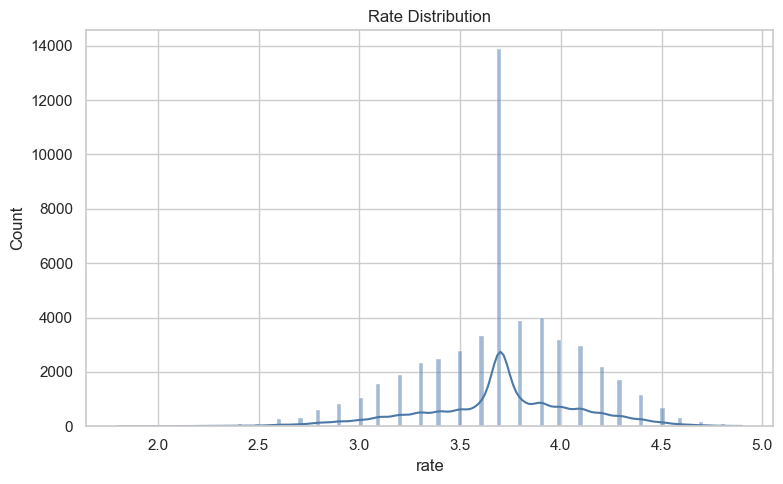

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df["rate"], kde=True, color="#4c78a8")
plt.title("Rate Distribution")
plt.tight_layout()
plt.show()

### Cell 4: Plot cost by online order
This graph shows whether restaurants with online ordering tend to have different price ranges.

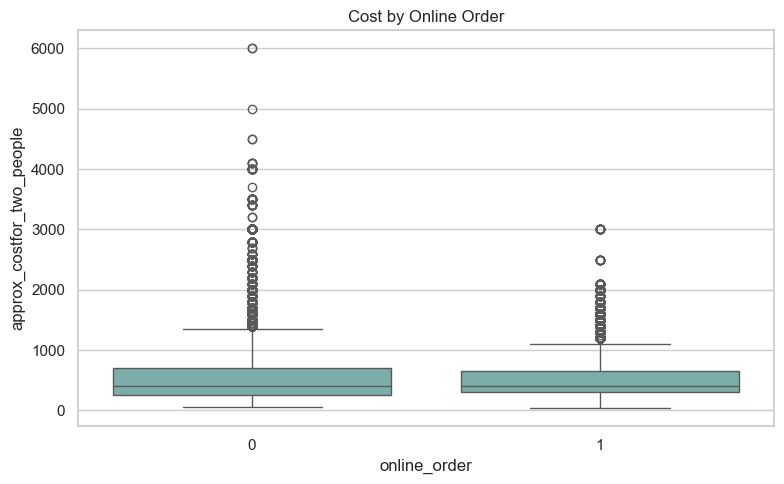

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="online_order", y="approx_costfor_two_people", color="#72b7b2")
plt.title("Cost by Online Order")
plt.tight_layout()
plt.show()

### Cell 5: Plot votes vs rate
This graph shows whether more popular restaurants also tend to have higher ratings.

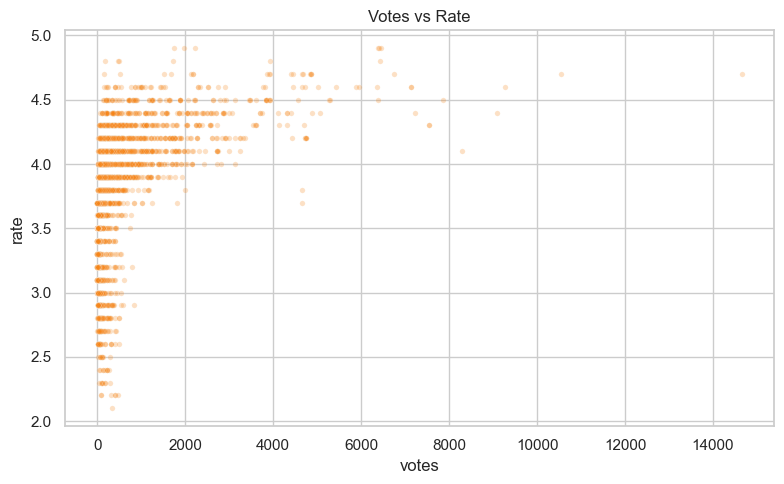

In [15]:
sample_df = df.sample(min(6000, len(df)), random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_df, x="votes", y="rate", alpha=0.25, s=15, color="#f58518")
plt.title("Votes vs Rate")
plt.tight_layout()
plt.show()

### Cell 6: Plot the correlation matrix
This heatmap gives a quick view of how the numeric variables move together.

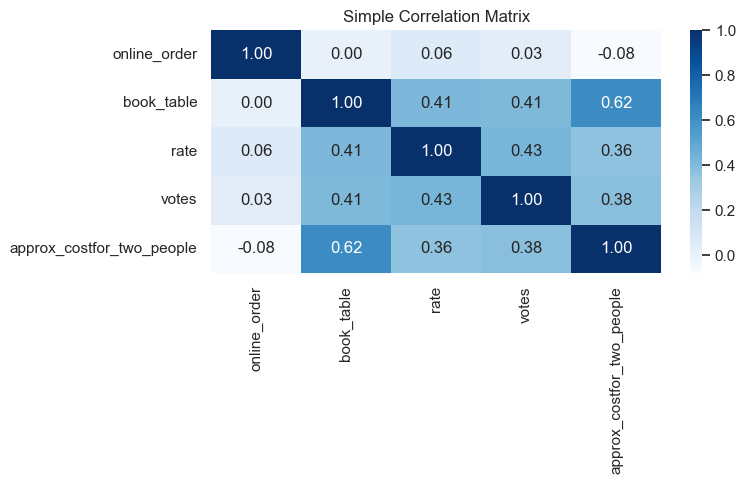

In [16]:
corr_cols = ["online_order", "book_table", "rate", "votes", "approx_costfor_two_people"]
plt.figure(figsize=(8, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Simple Correlation Matrix")
plt.tight_layout()
plt.show()

**Insight:** ratings are centered near 3.7, votes are right-skewed, and cost varies with service type and popularity.

## Final Summary

- Ratings are centered around the mid-to-high 3s, with a repeated imputed value that should be treated carefully.
- Votes and cost are right-skewed, so a few popular or premium restaurants stand out.
- Online ordering and table booking are useful grouping variables for simple comparisons.
- The main takeaway is that the dataset is clean enough for straightforward visual analysis and light statistical testing.

## Final Key Insights

- The cleaned dataset is analysis-ready with no missing values, but repeated imputed ratings should be interpreted carefully.
- Restaurant popularity (`votes`) and cost are both strongly right-skewed, indicating a small set of high-impact restaurants.
- Service features (`online_order`, `book_table`) are practical grouping variables for business-level comparisons.
- Correlation patterns suggest moderate relationships between rating, popularity, and price, which are useful for downstream modeling.